# Land Cover Change Detection: AOI and Imagery Exploration

This notebook defines the study area, searches Microsoft Planetary Computer for Sentinel-2 L2A imagery covering 2018–2025, and previews what we're working with before committing to the multi-hour compositing run in notebook 02.

**What we produce here:**
- `data/gsmnp_aoi.gpkg` — buffered GSMNP boundary in EPSG:5070 (analysis CRS)
- `data/gsmnp_aoi_4326.geojson` — same boundary in WGS84 (for STAC queries and web display)
- A scene inventory table: year, count, tiles, date range, median cloud cover
- A visual sanity check: one scene's RGB and SCL layer

In [1]:
!pip install pystac-client stackstac planetary-computer "dask[distributed]"

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 KB 306.7 kB/s eta 0:00:000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 KB 1.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 KB 3.8 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 KB 4.5 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.0 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 KB 821.2 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.1/406.1 KB 8.2 MB/s eta 0:00:0000:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-l

## Imports

All imports up front. `planetary_computer` handles token signing for Planetary Computer's SAS URLs — without it, asset links return 403s.

In [2]:
import os
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import planetary_computer
import pystac_client
import stackstac
import rioxarray
import xarray as xr
from shapely.geometry import box

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

## Study Area: GSMNP + 10 km Buffer

The analysis CRS is EPSG:5070 (NAD83 / Conus Albers) — a metric equal-area projection appropriate for the continental US. We buffer 10 km beyond the park boundary to capture edge dynamics and context.

GSMNP's official boundary shapefile comes from the SLF Project's NPS data download. We dissolve first in case the boundary is multi-part, then buffer in the metric CRS.

In [3]:
boundary_path = "../SLF Project/data/nps/BOUNDARY_PY.shp"
gsmnp = gpd.read_file(boundary_path)

# Dissolve to single polygon, reproject, buffer 10 km
aoi_5070 = (
    gsmnp
    .dissolve()
    .to_crs(5070)
    .buffer(10_000)
    .to_frame(name="geometry")
    .set_geometry("geometry")
)
aoi_5070.crs = "EPSG:5070"

print(f"Source CRS:  {gsmnp.crs}")
print(f"AOI CRS:     {aoi_5070.crs}")
print(f"Bounds (m):  {aoi_5070.total_bounds.round(0)}")
print(f"Area:        {aoi_5070.area.sum() / 1e6:.0f} km²")

Source CRS:  EPSG:26917
AOI CRS:     EPSG:5070
Bounds (m):  [1064249. 1436778. 1173240. 1508239.]
Area:        5103 km²


## Save AOI Files

Two formats:
- `.gpkg` in EPSG:5070 — loaded by every subsequent notebook for analysis
- `.geojson` in EPSG:4326 — used for STAC spatial queries (Planetary Computer expects WGS84 bbox)

In [4]:
aoi_5070.to_file(DATA_DIR / "gsmnp_aoi.gpkg", driver="GPKG")

aoi_4326 = aoi_5070.to_crs(4326)
aoi_4326.to_file(DATA_DIR / "gsmnp_aoi_4326.geojson", driver="GeoJSON")

bbox_4326 = aoi_4326.total_bounds  # [minx, miny, maxx, maxy]
print(f"Saved:       {DATA_DIR / 'gsmnp_aoi.gpkg'}")
print(f"Saved:       {DATA_DIR / 'gsmnp_aoi_4326.geojson'}")
print(f"STAC bbox:   {bbox_4326.round(4)}")

Saved:       data/gsmnp_aoi.gpkg
Saved:       data/gsmnp_aoi_4326.geojson
STAC bbox:   [-84.1252  35.3397 -82.8867  35.9307]


## Connect to Planetary Computer STAC

Planetary Computer's STAC catalog is public but asset URLs are time-limited SAS tokens. `planetary_computer.sign_inplace()` passed as the `modifier` parameter means the client re-signs URLs automatically whenever we access assets — no manual token management.

In [5]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print(f"Connected:   {catalog.title}")
print(f"Collections: {[c.id for c in catalog.get_collections() if 'sentinel' in c.id.lower()]}")

Connected:   Microsoft Planetary Computer STAC API
Collections: ['sentinel-1-rtc', 'sentinel-2-l2a', 'sentinel-1-grd', 'sentinel-5p-l2-netcdf', 'sentinel-3-olci-wfr-l2-netcdf', 'sentinel-3-synergy-aod-l2-netcdf', 'sentinel-3-synergy-v10-l2-netcdf', 'sentinel-3-olci-lfr-l2-netcdf', 'sentinel-3-sral-lan-l2-netcdf', 'sentinel-3-slstr-lst-l2-netcdf', 'sentinel-3-slstr-wst-l2-netcdf', 'sentinel-3-sral-wat-l2-netcdf', 'sentinel-3-slstr-frp-l2-netcdf', 'sentinel-3-synergy-syn-l2-netcdf', 'sentinel-3-synergy-vgp-l2-netcdf', 'sentinel-3-synergy-vg1-l2-netcdf']


## Scene Inventory: 2018–2025

We search July–August for each year — peak growing season, maximum NDVI, minimum cloud cover in the southern Appalachians. Cloud cover filter at 20% is per-scene metadata, not per-pixel; the SCL mask in notebook 02 handles residual clouds at the pixel level.

The loop builds a summary per year. If any year returns fewer than 4 scenes, note it — 2018 in particular had lower Sentinel-2 revisit frequency.

In [6]:
years = range(2018, 2026)
all_items = {}  # year -> list of STAC items
summary_rows = []

for year in years:
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox_4326.tolist(),
        datetime=f"{year}-07-01/{year}-08-31",
        query={"eo:cloud_cover": {"lt": 20}},
    )
    items = list(search.items())
    all_items[year] = items

    if items:
        dates = [i.datetime for i in items]
        clouds = [i.properties.get("eo:cloud_cover", np.nan) for i in items]
        tiles = sorted(set(i.properties.get("s2:mgrs_tile", "?") for i in items))
        baseline = [i.properties.get("s2:processing_baseline", "?") for i in items]
        summary_rows.append({
            "year": year,
            "scenes": len(items),
            "tiles": ", ".join(tiles),
            "date_range": f"{min(dates).date()} – {max(dates).date()}",
            "median_cloud": f"{np.nanmedian(clouds):.1f}%",
            "baseline": sorted(set(baseline))[0],
        })
    else:
        summary_rows.append({"year": year, "scenes": 0, "tiles": "—", "date_range": "—", "median_cloud": "—", "baseline": "—"})

summary = pd.DataFrame(summary_rows).set_index("year")
print(summary.to_string())

      scenes                tiles               date_range median_cloud baseline
year                                                                            
2018      17  16SGE, 17SKV, 17SLV  2018-07-04 – 2018-08-25        10.7%    02.12
2019      28  16SGE, 17SKV, 17SLV  2019-07-01 – 2019-08-30        11.1%    02.12
2020      20  16SGE, 17SKV, 17SLV  2020-07-03 – 2020-08-17        17.5%    02.12
2021      24  16SGE, 17SKV, 17SLV  2021-07-03 – 2021-08-29         9.5%    03.00
2022      12  16SGE, 17SKV, 17SLV  2022-07-23 – 2022-08-27        13.0%    04.00
2023      26  16SGE, 17SKV, 17SLV  2023-07-08 – 2023-08-27        14.9%    05.09
2024      21  16SGE, 17SKV, 17SLV  2024-07-12 – 2024-08-31        10.9%    05.10
2025      21  16SGE, 17SKV, 17SLV  2025-07-04 – 2025-08-30        13.3%    05.11


Check the scene counts. 8–20 per year is expected. If 2018 has fewer than 4, revisit the compositing strategy for that year — a 3-month window (Jun–Aug) might be needed.

The `baseline` column should show `04.00` or higher for Collection 1 consistent atmospheric correction. Mixed baselines across years could introduce systematic NDVI offsets; they would show up as a step change in the time series even over stable vegetation.

## Scene Preview: RGB + SCL

Pull one scene from the most recent year with good coverage and display it as true-color (B04/B03/B02) and its Scene Classification Layer. The SCL tells us what the cloud mask will keep and discard.

SCL class meanings relevant to our mask:
- **4** Vegetation — keep
- **5** Bare soil — keep  
- **6** Water — keep
- **3** Cloud shadow — discard
- **8/9** Cloud — discard
- **2** Dark area / terrain shadow — discard

In [7]:
# Pick the least-cloudy scene from the most recent year with scenes
preview_year = max(y for y in years if all_items[y])
preview_items = sorted(all_items[preview_year], key=lambda i: i.properties.get("eo:cloud_cover", 100))
preview_item = preview_items[0]

print(f"Preview scene: {preview_item.id}")
print(f"Date:          {preview_item.datetime.date()}")
print(f"Cloud cover:   {preview_item.properties['eo:cloud_cover']:.1f}%")
print(f"MGRS tile:     {preview_item.properties.get('s2:mgrs_tile')}")
print(f"Baseline:      {preview_item.properties.get('s2:processing_baseline')}")

Preview scene: S2A_MSIL2A_20250724T162711_R040_T17SLV_20250725T005716
Date:          2025-07-24
Cloud cover:   5.5%
MGRS tile:     17SLV
Baseline:      05.11


In [8]:
# Stack RGB bands and SCL, clip to AOI bbox, compute
# stackstac fetches only the pixel ranges we need via COG range requests
aoi_geom = aoi_4326.geometry.iloc[0]

da_rgb = stackstac.stack(
    [preview_item],
    assets=["B04", "B03", "B02"],
    epsg=5070,
    resolution=10,
    bounds_latlon=aoi_geom.bounds,
).squeeze("time")

da_scl = stackstac.stack(
    [preview_item],
    assets=["SCL"],
    epsg=5070,
    resolution=10,
    bounds_latlon=aoi_geom.bounds,
).squeeze("time").squeeze("band")

rgb = da_rgb.compute()
scl = da_scl.compute()

print(f"RGB shape: {rgb.shape}  (bands, rows, cols)")
print(f"SCL shape: {scl.shape}")

RGB shape: (3, 8018, 11890)  (bands, rows, cols)
SCL shape: (8018, 11890)


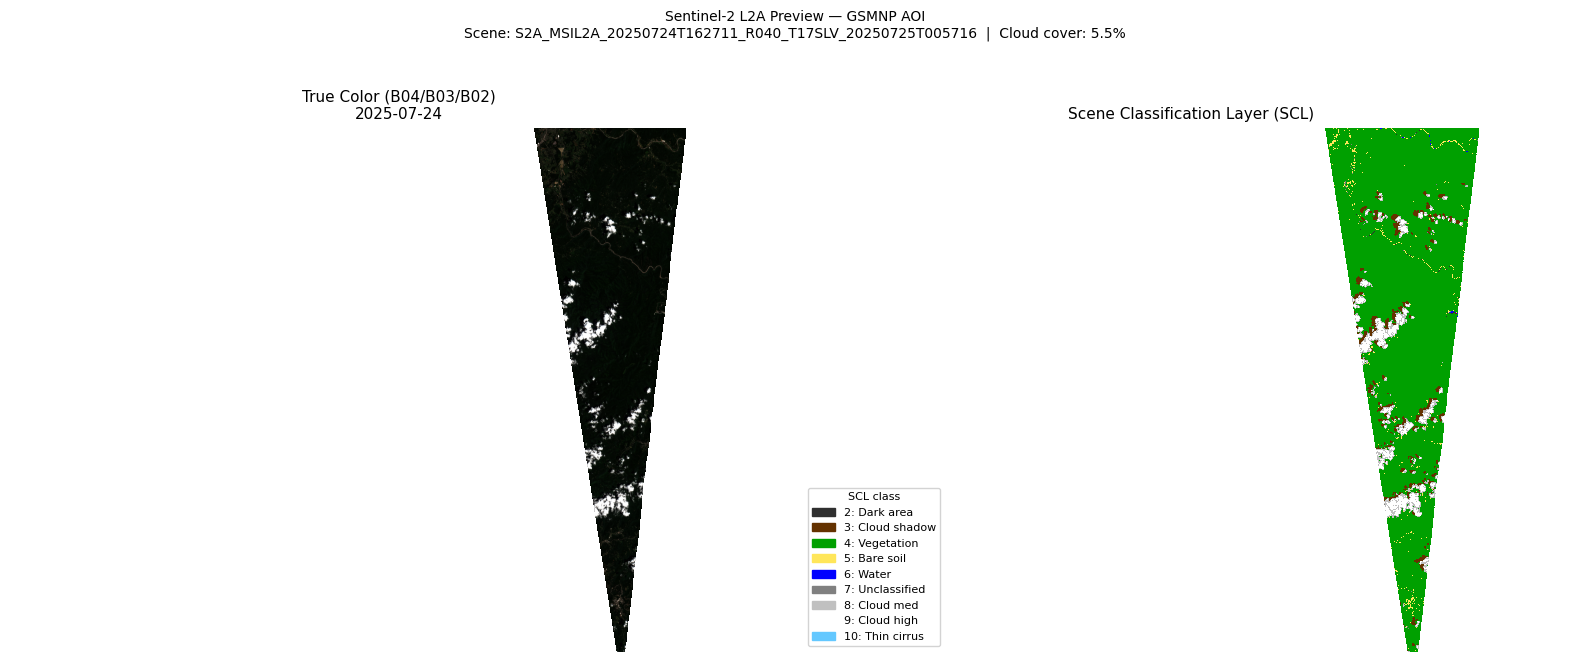


SCL class breakdown:
   2 Dark area       [mask]    0.1%
   3 Cloud shadow    [mask]    3.6%
   4 Vegetation      [KEEP]   86.9%
   5 Bare soil       [KEEP]    1.3%
   6 Water           [KEEP]    0.1%
   7 Unclassified    [mask]    0.2%
   8 Cloud med       [mask]    4.1%
   9 Cloud high      [mask]    3.8%
  10 Thin cirrus     [mask]    0.0%


In [9]:
# Normalize RGB for display: clip to 2nd–98th percentile, scale to [0,1]
def norm_band(arr):
    lo, hi = np.nanpercentile(arr, [2, 98])
    return np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)

rgb_display = np.stack([
    norm_band(rgb.sel(band="B04").values),
    norm_band(rgb.sel(band="B03").values),
    norm_band(rgb.sel(band="B02").values),
], axis=-1)

# SCL color map: 12 classes (0–11)
scl_colors = [
    "#000000",  # 0  No data
    "#ff0000",  # 1  Saturated/defective
    "#2f2f2f",  # 2  Dark area pixels
    "#643200",  # 3  Cloud shadow
    "#00a000",  # 4  Vegetation
    "#ffe65a",  # 5  Bare soils
    "#0000ff",  # 6  Water
    "#808080",  # 7  Unclassified
    "#c0c0c0",  # 8  Cloud medium prob
    "#ffffff",  # 9  Cloud high prob
    "#64c8ff",  # 10 Thin cirrus
    "#ff96ff",  # 11 Snow/Ice
]
scl_cmap = mcolors.ListedColormap(scl_colors)
scl_labels = ["No data", "Saturated", "Dark area", "Cloud shadow",
               "Vegetation", "Bare soil", "Water", "Unclassified",
               "Cloud med", "Cloud high", "Thin cirrus", "Snow/Ice"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(rgb_display)
axes[0].set_title(f"True Color (B04/B03/B02)\n{preview_item.datetime.date()}", fontsize=11)
axes[0].axis("off")

im = axes[1].imshow(scl.values, cmap=scl_cmap, vmin=-0.5, vmax=11.5, interpolation="nearest")
axes[1].set_title("Scene Classification Layer (SCL)", fontsize=11)
axes[1].axis("off")

# Legend for SCL
present_classes = np.unique(scl.values[~np.isnan(scl.values)]).astype(int)
patches = [mpatches.Patch(color=scl_colors[c], label=f"{c}: {scl_labels[c]}")
           for c in present_classes if c < len(scl_colors)]
axes[1].legend(handles=patches, loc="lower left", fontsize=8, framealpha=0.85,
               title="SCL class", title_fontsize=8)

plt.suptitle(
    f"Sentinel-2 L2A Preview — GSMNP AOI\n"
    f"Scene: {preview_item.id}  |  Cloud cover: {preview_item.properties['eo:cloud_cover']:.1f}%",
    fontsize=10, y=1.01
)
plt.tight_layout()
plt.show()

# Quick SCL stats
scl_vals, scl_counts = np.unique(scl.values[~np.isnan(scl.values)].astype(int), return_counts=True)
total_px = scl_counts.sum()
print("\nSCL class breakdown:")
for v, c in zip(scl_vals, scl_counts):
    label = scl_labels[v] if v < len(scl_labels) else "?"
    keep = "[KEEP]" if v in {4, 5, 6} else "[mask]"
    print(f"  {v:2d} {label:<15s} {keep}  {c/total_px*100:5.1f}%")

## What to Check Before Proceeding to Notebook 02

- Scene counts 8–20 per year. If 2018 < 4, you may want to widen its date range to June–August in the compositing step.
- RGB preview shows the Smokies — recognizable terrain, vegetation, no obvious CRS mismatch.
- SCL shows vegetation (class 4) dominating the forested areas, clouds/shadow flagged plausibly.
- Processing baseline `04.00` or higher for Collection 1 consistency.

If those look reasonable, move on to `02_lccd_composites.ipynb`.